In [19]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [20]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [21]:
sc.settings.set_figure_params(dpi=80)

# Variables

In [7]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
adata_path = f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad'
embedding_basis = 'X_umap_scVI_n-layers-3'
coarse_label_col = 'coarse_grain_tacco_ref-hd-scn' 

In [15]:
subset_adata_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
fine_grain_col_subsets = 'fine_grain'
fine_grain_col_toadd = 'fine_grain_2Feb2026'

In [7]:
os.getcwd()

'/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/VisiumHD/Revision_Oct2025/4_fine-grain_annotation'

# Read in data

In [8]:
adata= sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 213873 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor_colors', 'library_colors', 'neighbors', 'uma

In [9]:
adata.X.data[:5]

array([1., 1., 1., 1., 1.])

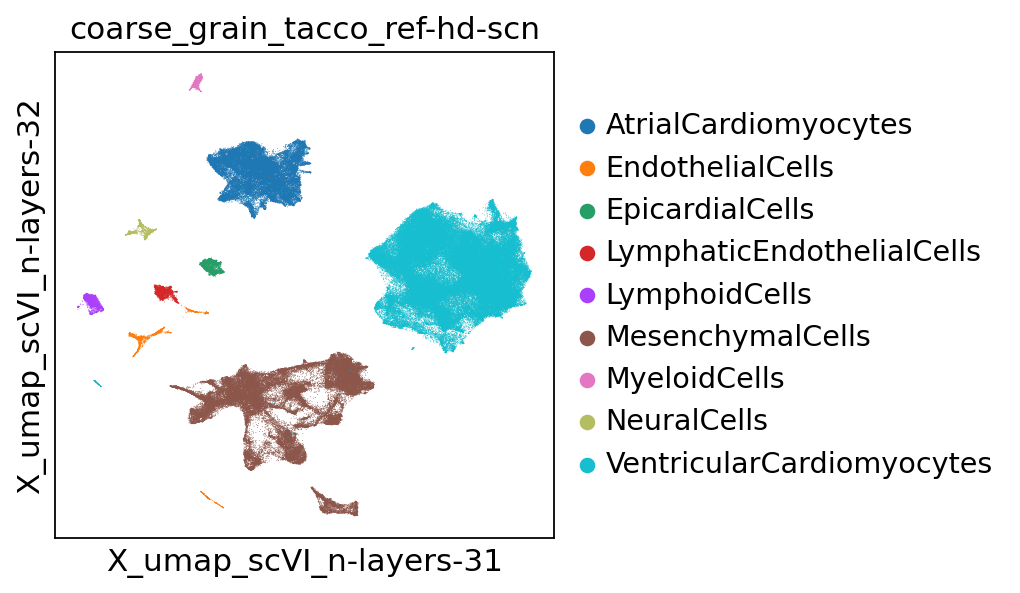

In [10]:
sc.pl.embedding(adata,
                    basis=embedding_basis,
                    color=coarse_label_col,
                # groups='unassigned',
                   ncols=4
                   )

# Add fine-grained annotation

In [11]:
!ls {subset_adata_dir}

b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
b2c_cells_EndothelialCells_lognorm.h5ad
b2c_cells_EndothelialCells_raw.h5ad
b2c_cells_EpicardialCells_lognorm.h5ad
b2c_cells_EpicardialCells_raw.h5ad
b2c_cells_LymphoidCells_lognorm.h5ad
b2c_cells_LymphoidCells_raw.h5ad
b2c_cells_MesenchymalCells_lognorm.h5ad
b2c_cells_MesenchymalCells_raw.h5ad
b2c_cells_MyeloidCells_lognorm.h5ad
b2c_cells_MyeloidCells_raw.h5ad
b2c_cells_NeuralCells_lognorm.h5ad
b2c_cells_NeuralCells_raw.h5ad
b2c_cells_VentricularCardiomyocytes_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_raw.h5ad
scVI


In [12]:
adata.obs[fine_grain_col_toadd] =  adata.obs[coarse_label_col].astype('str').copy()

In [13]:
file_list = os.listdir(subset_adata_dir)
celltypes_to_add = [x.split('_')[2] for x in file_list if '_lognorm.h5ad' in x]
celltypes_to_add

['EndothelialCells',
 'AtrialCardiomyocytes',
 'NeuralCells',
 'MyeloidCells',
 'VentricularCardiomyocytes',
 'EpicardialCells',
 'MesenchymalCells',
 'LymphoidCells']

In [14]:
for celltype in celltypes_to_add:
    print(celltype)
    if celltype=='LymphaticEndothelialCells':
        print('skip since the label of mid-grain and fine-grain are same')
        continue
    ad = sc.read_h5ad(f'{subset_adata_dir}/b2c_cells_{celltype}_lognorm.h5ad',backed='r')
    print(ad.shape)
    # add cell type labels
    adata.obs.loc[ad.obs_names,fine_grain_col_toadd] = ad.obs[fine_grain_col_subsets]
adata.obs[fine_grain_col_toadd].value_counts()

EndothelialCells
(2878, 14610)
AtrialCardiomyocytes
(34193, 17854)
NeuralCells
(1501, 15646)
MyeloidCells
(1203, 13617)
VentricularCardiomyocytes
(114538, 18039)
EpicardialCells
(2399, 13773)
MesenchymalCells
(52703, 18028)
LymphoidCells
(2289, 12239)


fine_grain_2Feb2026
VentricularCardiomyocytesCompact         70002
Fibroblasts                              24614
VentricularCardiomyocytesTrabeculated    16973
VentricularConductionSystemProximal      13953
Erythrocytes                             13086
ValveInterstitialCells                   12968
AtrialCardiomyocytesRight                 9684
AtrialCardiomyocytesLeft                  8366
SinoatrialNodePacemakerCells              6272
GreatVesselSmoothMuscleCells              5380
AtrioventricularNodePacemakerCells        5025
Doublets                                  4040
FibroblastsCOL2A1pos                      3173
LowCounts                                 2563
DuctusArteriosusSmoothMuscleCells         2461
LymphaticEndothelialCells                 2169
VentricularConductionSystemDistal         1794
AtrialCardiomyocytesTransitional          1604
unclassified                              1120
MesothelialEpicardialCells                1072
CoronaryMuralCells                      

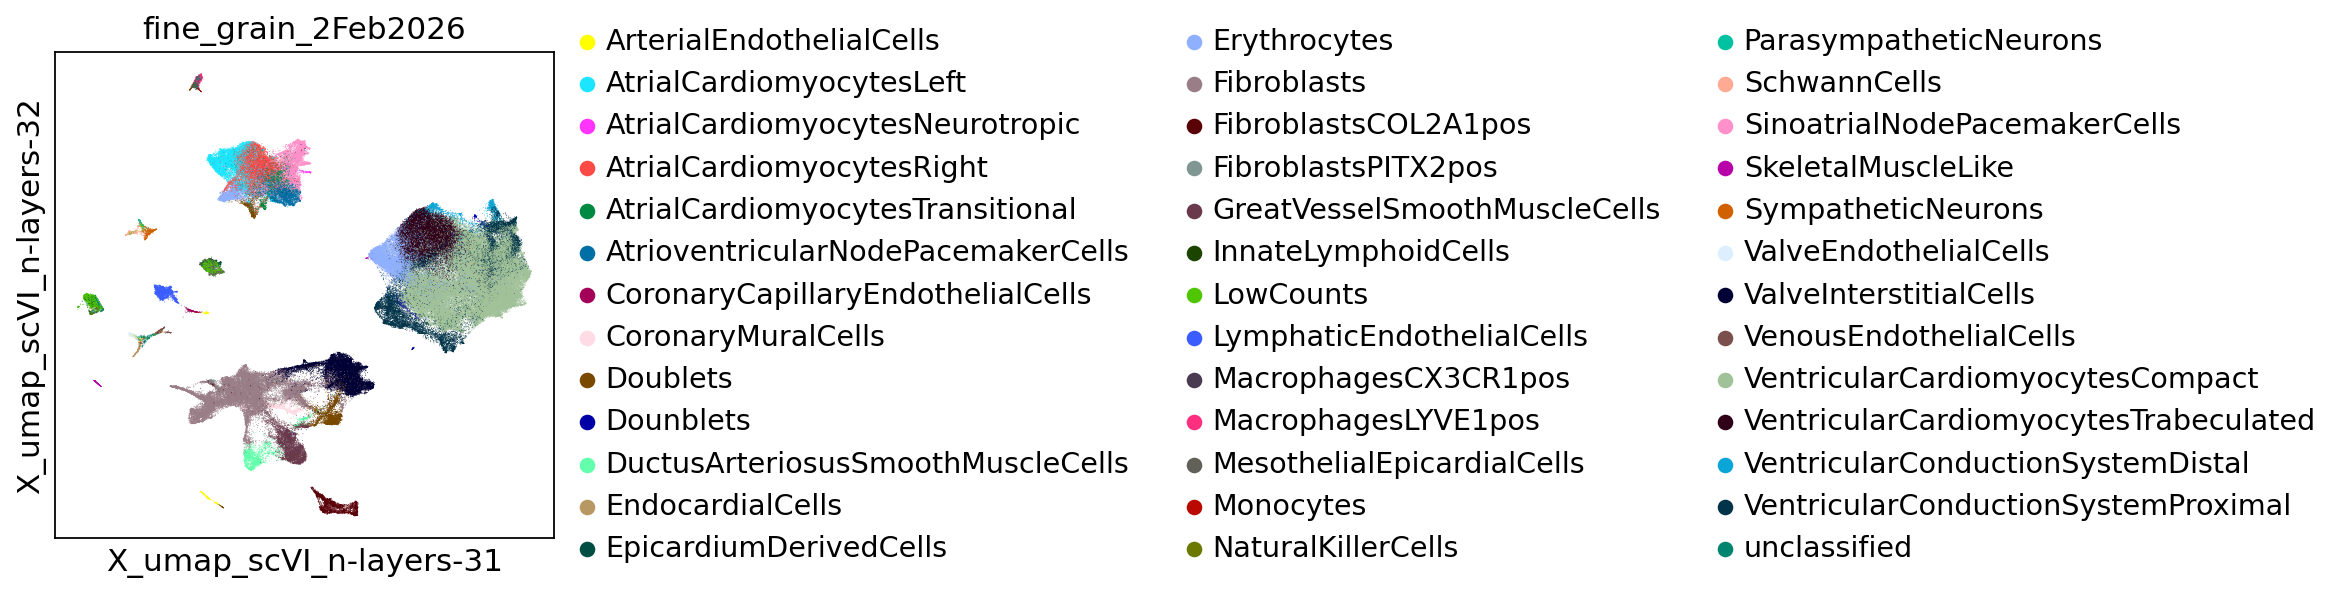

In [16]:
sc.pl.embedding(adata,basis=embedding_basis,color=[fine_grain_col_toadd],wspace=0.2,cmap='RdPu')

In [18]:
len(set(adata.obs[fine_grain_col_toadd]))

43

# Add SAN-PC annotations

In [13]:
adata = sc.read_h5ad(adata_path)

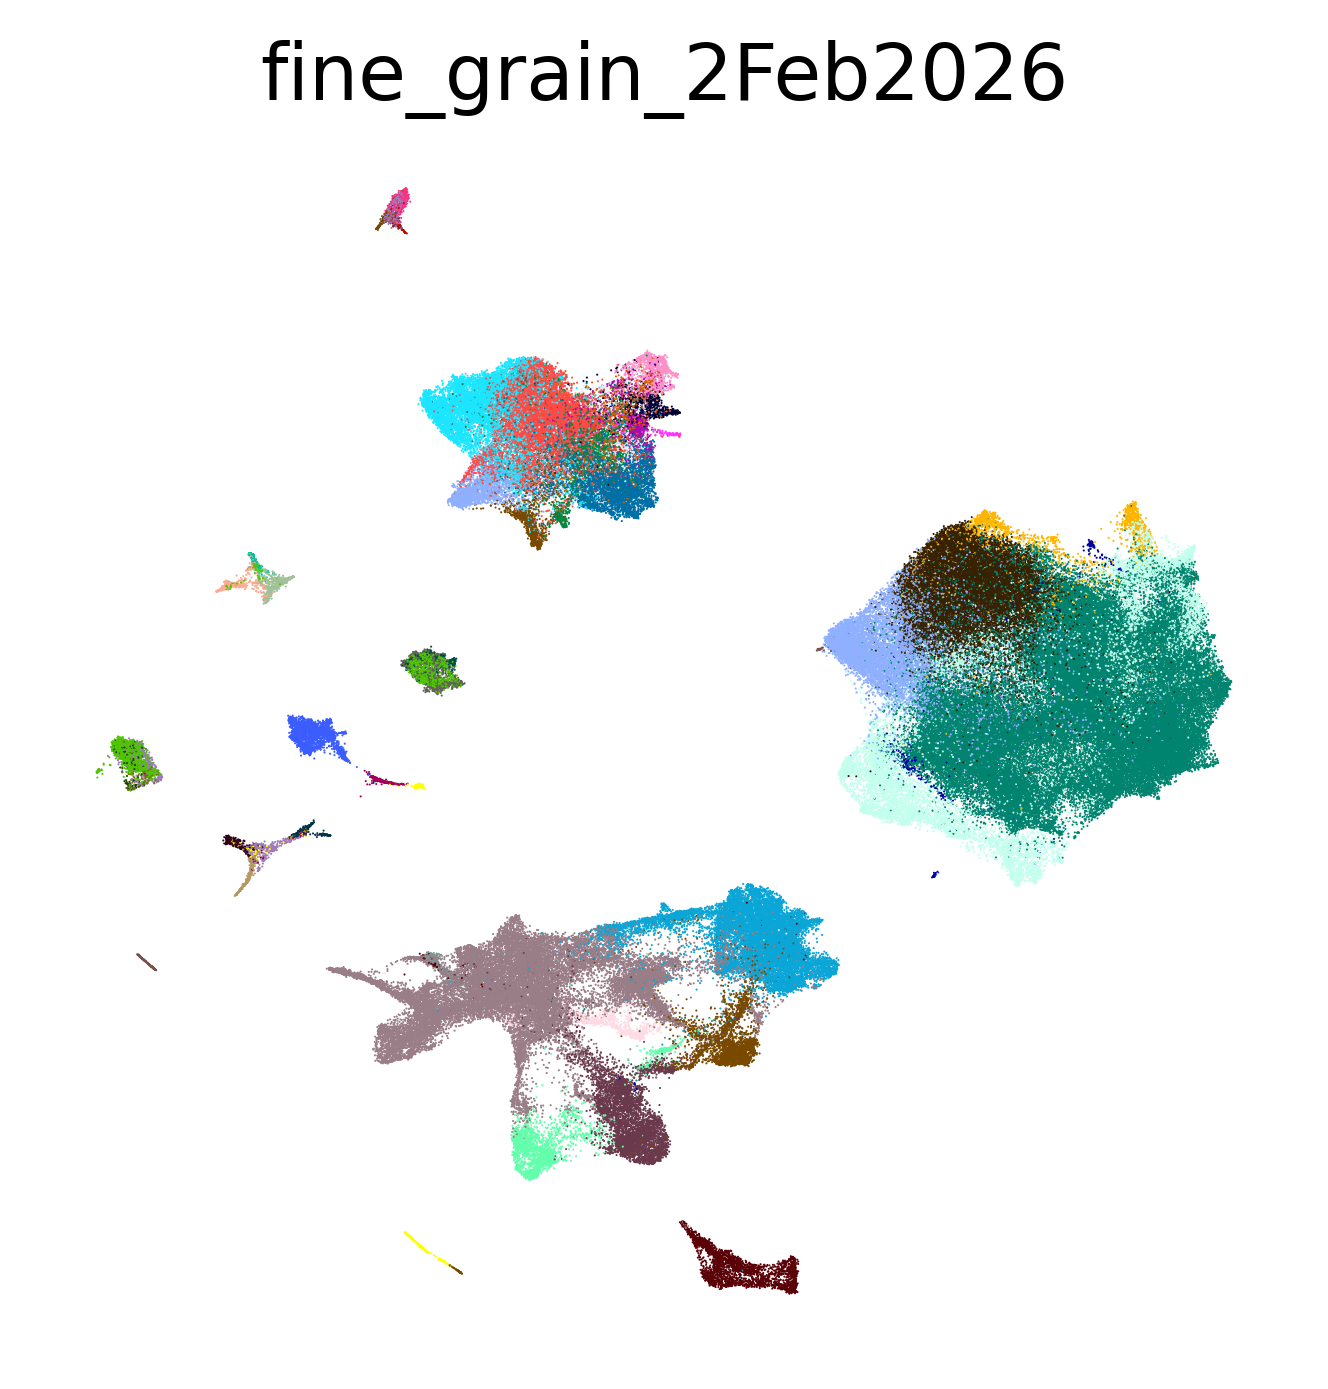

In [17]:
sc.settings.set_figure_params(dpi=200)
sc.pl.embedding(adata,basis=embedding_basis,color=[fine_grain_col_toadd],frameon=False,legend_loc=None)
sc.settings.set_figure_params(dpi=80)

In [8]:
# read in atrialCM data
adata_acm = sc.read_h5ad(f'{data_object_dir}/TACCO/coarse_grain_subsets/b2c_cells_AtrialCardiomyocytes_lognorm.h5ad')
adata_acm

AnnData object with n_obs × n_vars = 34193 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_m

In [10]:
adata.obs[fine_grain_col_toadd] = adata.obs[fine_grain_col_toadd].astype('str')
adata.obs.loc[adata_acm.obs_names,fine_grain_col_toadd] = adata_acm.obs['fine_grain2'].copy()
set(adata.obs[fine_grain_col_toadd])

{'ArterialEndothelialCells',
 'AtrialCardiomyocytesLeft',
 'AtrialCardiomyocytesNeurotropic',
 'AtrialCardiomyocytesRight',
 'AtrialCardiomyocytesTransitional',
 'AtrioventricularNodePacemakerCells',
 'CoronaryCapillaryEndothelialCells',
 'CoronaryMuralCells',
 'Doublets',
 'Dounblets',
 'DuctusArteriosusSmoothMuscleCells',
 'EndocardialCells',
 'EpicardiumDerivedCells',
 'Erythrocytes',
 'Fibroblasts',
 'FibroblastsCOL2A1pos',
 'FibroblastsPITX2pos',
 'GreatVesselSmoothMuscleCells',
 'InnateLymphoidCells',
 'LowCounts',
 'LymphaticEndothelialCells',
 'MacrophagesCX3CR1pos',
 'MacrophagesLYVE1pos',
 'MesothelialEpicardialCells',
 'Monocytes',
 'NaturalKillerCells',
 'ParasympatheticNeurons',
 'SchwannCells',
 'SinoatrialNodePacemakerCellsHead',
 'SinoatrialNodePacemakerCellsTail',
 'SinoatrialNodePacemakerCells_lowcounts',
 'SinoatrialNodePacemakerCells_unclassified',
 'SinusHornPacemakerCells',
 'SkeletalMuscleLike',
 'SympatheticNeurons',
 'ValveEndothelialCells',
 'ValveInterstitial

# Save

Save two versions as below
- As the current object is
- Clean version: remove doublet and unclassified cells

In [11]:
# as the current object is
adata.write(adata_path)
print(adata_path)

/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/tacco-splitted_ref-HD-SCN_filtered_raw.h5ad


In [12]:
print(adata.X.data[:10])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [14]:
# clean version
cells_to_keep = [
    'ArterialEndothelialCells',
     'AtrialCardiomyocytesLeft',
     'AtrialCardiomyocytesNeurotropic',
     'AtrialCardiomyocytesRight',
     'AtrialCardiomyocytesTransitional',
     'AtrioventricularNodePacemakerCells',
     'CoronaryCapillaryEndothelialCells',
     'CoronaryMuralCells',
     # 'Doublets',
     # 'Dounblets',
     'DuctusArteriosusSmoothMuscleCells',
     'EndocardialCells',
     'EpicardiumDerivedCells',
     # 'Erythrocytes',
     'Fibroblasts',
     'FibroblastsCOL2A1pos',
     'FibroblastsPITX2pos',
     'GreatVesselSmoothMuscleCells',
     'InnateLymphoidCells',
     # 'LowCounts',
     'LymphaticEndothelialCells',
     'MacrophagesCX3CR1pos',
     'MacrophagesLYVE1pos',
     'MesothelialEpicardialCells',
     'Monocytes',
     'NaturalKillerCells',
     'ParasympatheticNeurons',
     'SchwannCells',
     'SinoatrialNodePacemakerCellsHead',
     'SinoatrialNodePacemakerCellsTail',
     # 'SinoatrialNodePacemakerCells_lowcounts',
     # 'SinoatrialNodePacemakerCells_unclassified',
     'SinusHornPacemakerCells',
     # 'SkeletalMuscleLike',
     'SympatheticNeurons',
     'ValveEndothelialCells',
     'ValveInterstitialCells',
     'VenousEndothelialCells',
     'VentricularCardiomyocytesCompact',
     'VentricularCardiomyocytesTrabeculated',
     'VentricularConductionSystemDistal',
     'VentricularConductionSystemProximal',
     # 'unclassified'   
]

adata_clean = adata[adata.obs[fine_grain_col_toadd].isin(cells_to_keep)]
print(adata_clean.shape)
adata_clean.obs[fine_grain_col_toadd].value_counts()

(189948, 18077)


fine_grain_2Feb2026
VentricularCardiomyocytesCompact         70002
Fibroblasts                              24614
VentricularCardiomyocytesTrabeculated    16973
VentricularConductionSystemProximal      13953
ValveInterstitialCells                   12968
AtrialCardiomyocytesRight                 9684
AtrialCardiomyocytesLeft                  8366
AtrioventricularNodePacemakerCells        5661
GreatVesselSmoothMuscleCells              5380
FibroblastsCOL2A1pos                      3173
DuctusArteriosusSmoothMuscleCells         2461
LymphaticEndothelialCells                 2169
VentricularConductionSystemDistal         1794
AtrialCardiomyocytesTransitional          1604
SinoatrialNodePacemakerCellsHead          1319
SinoatrialNodePacemakerCellsTail          1198
MesothelialEpicardialCells                1072
CoronaryMuralCells                        1056
SinusHornPacemakerCells                    863
ArterialEndothelialCells                   724
SympatheticNeurons                      

In [15]:
# save
adata_clean.write(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad')

# Add annotations to the original (pre-TACCO) objects

In [23]:
# read in post-TACCO objects with annotations
adata = sc.read_h5ad(adata_path, backed='r')
print(adata.shape)

adata_clean = sc.read_h5ad(f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad',
                           backed='r')
print(adata_clean.shape)

(213873, 18077)
(189948, 18077)


In [24]:
!ls {data_object_dir}

all_b2c_cells_filtered_celltype-sel_raw.h5ad
all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad
all_b2c_cells_filtered_raw.h5ad
all_b2c_cells_raw.h5ad
archive_17Nov2025
epicardium-mixture_b2c_cells_filtered_raw.h5ad
erythrocytes_b2c_cells_filtered_raw.h5ad
scVI
TACCO
unclassified-mixture_b2c_cells_filtered_raw.h5ad


### To the "celltype-selected" objets (NO erythrocytes, megakaryocytes, epithelial cells)

In [15]:
# read in pre-TACCO object
adata_preTACCO = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_raw.h5ad')
adata_preTACCO

AnnData object with n_obs × n_vars = 217420 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_pre_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'spatial', 'spatial_cropped_150_buffer'
    obsp: 'connectivities', 'dist

In [21]:
celltype_label_cols = ['coarse_grain_tacco_ref-hd-scn','fine_grain_2Feb2026']
adata_preTACCO.obs[celltype_label_cols] = adata.obs[celltype_label_cols].reindex(adata_preTACCO.obs_names)
print(f"number of NaN: {adata_preTACCO.obs['fine_grain_2Feb2026'].isna().sum()}")
adata_preTACCO.obs[celltype_label_cols].value_counts()

number of NaN: 3547


coarse_grain_tacco_ref-hd-scn  fine_grain_2Feb2026                      
VentricularCardiomyocytes      VentricularCardiomyocytesCompact             70002
MesenchymalCells               Fibroblasts                                  24614
VentricularCardiomyocytes      VentricularCardiomyocytesTrabeculated        16973
                               VentricularConductionSystemProximal          13953
MesenchymalCells               ValveInterstitialCells                       12968
VentricularCardiomyocytes      Erythrocytes                                 10956
AtrialCardiomyocytes           AtrialCardiomyocytesRight                     9684
                               AtrialCardiomyocytesLeft                      8366
                               AtrioventricularNodePacemakerCells            5661
MesenchymalCells               GreatVesselSmoothMuscleCells                  5380
                               FibroblastsCOL2A1pos                          3173
                         

In [23]:
# make clean version
adata_preTACCO_clean = adata_preTACCO[adata_clean.obs_names].copy()
print(adata_preTACCO_clean.shape)
print(f"number of NaN: {adata_preTACCO_clean.obs['fine_grain_2Feb2026'].isna().sum()}")
adata_preTACCO_clean.obs[celltype_label_cols].value_counts()

(189948, 18085)
number of NaN: 0


coarse_grain_tacco_ref-hd-scn  fine_grain_2Feb2026                  
VentricularCardiomyocytes      VentricularCardiomyocytesCompact         70002
MesenchymalCells               Fibroblasts                              24614
VentricularCardiomyocytes      VentricularCardiomyocytesTrabeculated    16973
                               VentricularConductionSystemProximal      13953
MesenchymalCells               ValveInterstitialCells                   12968
AtrialCardiomyocytes           AtrialCardiomyocytesRight                 9684
                               AtrialCardiomyocytesLeft                  8366
                               AtrioventricularNodePacemakerCells        5661
MesenchymalCells               GreatVesselSmoothMuscleCells              5380
                               FibroblastsCOL2A1pos                      3173
                               DuctusArteriosusSmoothMuscleCells         2461
LymphaticEndothelialCells      LymphaticEndothelialCells                 

In [24]:
print(adata_preTACCO.X.data[:10])

[1. 1. 1. 1. 1. 1. 1. 2. 1. 1.]


In [25]:
# save
adata_preTACCO.write(f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_raw.h5ad')
adata_preTACCO_clean.write(f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad')

### To the objet which includes all the qualified cells

In [22]:
# read in pre-TACCO object
adata_preTACCO_all = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')

In [25]:
celltype_label_cols = ['coarse_grain_tacco_ref-hd-scn','fine_grain_2Feb2026']

for label_col in celltype_label_cols:
    # make basis
    adata_preTACCO_all.obs[label_col] = 'unclassified'
    # add
    adata_preTACCO_all.obs.loc[adata.obs_names,label_col] = adata.obs[label_col].astype('str').copy()

print(f"number of NaN: {adata_preTACCO_all.obs['coarse_grain_tacco_ref-hd-scn'].isna().sum()}")
print(f"number of NaN: {adata_preTACCO_all.obs['fine_grain_2Feb2026'].isna().sum()}")

number of NaN: 0
number of NaN: 0


In [26]:
pd.crosstab(adata_preTACCO_all.obs['coarse_grain_tacco_ref-hd-scn'],
           adata_preTACCO_all.obs['fine_grain_2Feb2026']).T

coarse_grain_tacco_ref-hd-scn,AtrialCardiomyocytes,EndothelialCells,EpicardialCells,LymphaticEndothelialCells,LymphoidCells,MesenchymalCells,MyeloidCells,NeuralCells,VentricularCardiomyocytes,unclassified
fine_grain_2Feb2026,,,,,,,,,,
ArterialEndothelialCells,0,724,0,0,0,0,0,0,0,0
AtrialCardiomyocytesLeft,8366,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesNeurotropic,123,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesRight,9684,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesTransitional,1604,0,0,0,0,0,0,0,0,0
AtrioventricularNodePacemakerCells,5661,0,0,0,0,0,0,0,0,0
CoronaryCapillaryEndothelialCells,0,340,0,0,0,0,0,0,0,0
CoronaryMuralCells,0,0,0,0,0,1056,0,0,0,0
Doublets,989,101,0,0,0,2815,135,0,0,0


In [30]:
# rename other unclassified cells
adata_preTACCO_all.obs['fine_grain_2Feb2026_mod'] = adata_preTACCO_all.obs['fine_grain_2Feb2026'].astype('str').copy()
adata_preTACCO_all.obs.replace({'fine_grain_2Feb2026_mod':{
   # 'ArterialEndothelialCells',
   # 'AtrialCardiomyocytesLeft',
   # 'AtrialCardiomyocytesNeurotropic',
   # 'AtrialCardiomyocytesRight',
   # 'AtrialCardiomyocytesTransitional',
   # 'AtrioventricularNodePacemakerCells',
   # 'CoronaryCapillaryEndothelialCells',
   # 'CoronaryMuralCells',
 'Doublets':'unclassified',
 'Dounblets':'unclassified',
   # 'DuctusArteriosusSmoothMuscleCells',
   # 'EndocardialCells',
   # 'EpicardiumDerivedCells',
   # 'Erythrocytes',
   # 'Fibroblasts',
   # 'FibroblastsCOL2A1pos',
   # 'FibroblastsPITX2pos',
   # 'GreatVesselSmoothMuscleCells',
   # 'InnateLymphoidCells',
 'LowCounts':'unclassified',
   # 'LymphaticEndothelialCells',
   # 'MacrophagesCX3CR1pos',
   # 'MacrophagesLYVE1pos',
   # 'MesothelialEpicardialCells',
   # 'Monocytes',
   # 'NaturalKillerCells',
   # 'ParasympatheticNeurons',
   # 'SchwannCells',
   # 'SinoatrialNodePacemakerCellsHead',
   # 'SinoatrialNodePacemakerCellsTail',
 'SinoatrialNodePacemakerCells_lowcounts':'unclassified',
 'SinoatrialNodePacemakerCells_unclassified':'unclassified',
   # 'SinusHornPacemakerCells',
   # 'SkeletalMuscleLike',
   # 'SympatheticNeurons',
   # 'ValveEndothelialCells',
   # 'ValveInterstitialCells',
   # 'VenousEndothelialCells',
   # 'VentricularCardiomyocytesCompact',
   # 'VentricularCardiomyocytesTrabeculated',
   # 'VentricularConductionSystemDistal',
   # 'VentricularConductionSystemProximal',
   # 'unclassified'
}},inplace=True)
set(adata_preTACCO_all.obs['fine_grain_2Feb2026_mod'])

{'ArterialEndothelialCells',
 'AtrialCardiomyocytesLeft',
 'AtrialCardiomyocytesNeurotropic',
 'AtrialCardiomyocytesRight',
 'AtrialCardiomyocytesTransitional',
 'AtrioventricularNodePacemakerCells',
 'CoronaryCapillaryEndothelialCells',
 'CoronaryMuralCells',
 'DuctusArteriosusSmoothMuscleCells',
 'EndocardialCells',
 'EpicardiumDerivedCells',
 'Erythrocytes',
 'Fibroblasts',
 'FibroblastsCOL2A1pos',
 'FibroblastsPITX2pos',
 'GreatVesselSmoothMuscleCells',
 'InnateLymphoidCells',
 'LymphaticEndothelialCells',
 'MacrophagesCX3CR1pos',
 'MacrophagesLYVE1pos',
 'MesothelialEpicardialCells',
 'Monocytes',
 'NaturalKillerCells',
 'ParasympatheticNeurons',
 'SchwannCells',
 'SinoatrialNodePacemakerCellsHead',
 'SinoatrialNodePacemakerCellsTail',
 'SinusHornPacemakerCells',
 'SkeletalMuscleLike',
 'SympatheticNeurons',
 'ValveEndothelialCells',
 'ValveInterstitialCells',
 'VenousEndothelialCells',
 'VentricularCardiomyocytesCompact',
 'VentricularCardiomyocytesTrabeculated',
 'VentricularCon

In [31]:
pd.crosstab(adata_preTACCO_all.obs['coarse_grain_tacco_ref-hd-scn'],
           adata_preTACCO_all.obs['fine_grain_2Feb2026_mod']).T

coarse_grain_tacco_ref-hd-scn,AtrialCardiomyocytes,EndothelialCells,EpicardialCells,LymphaticEndothelialCells,LymphoidCells,MesenchymalCells,MyeloidCells,NeuralCells,VentricularCardiomyocytes,unclassified
fine_grain_2Feb2026_mod,,,,,,,,,,
ArterialEndothelialCells,0,724,0,0,0,0,0,0,0,0
AtrialCardiomyocytesLeft,8366,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesNeurotropic,123,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesRight,9684,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesTransitional,1604,0,0,0,0,0,0,0,0,0
AtrioventricularNodePacemakerCells,5661,0,0,0,0,0,0,0,0,0
CoronaryCapillaryEndothelialCells,0,340,0,0,0,0,0,0,0,0
CoronaryMuralCells,0,0,0,0,0,1056,0,0,0,0
DuctusArteriosusSmoothMuscleCells,0,0,0,0,0,2461,0,0,0,0


In [32]:
# save
adata_preTACCO_all.write(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')